In [388]:
import numpy as np
import matplotlib.pyplot as plt

### Part 1

In [389]:
def cost(n, route, points, M=None):
    res = 0
    for i in range(n-1):
        p1 = route[i]
        p2 = route[i+1]
        res += np.sum(np.sqrt((points[:,p1]-points[:,p2])**2))
    res += np.sum(np.sqrt((points[:,route[-1]]-points[:,route[0]])**2))
    return res


def swap(n, ns, route, rng):
    new = np.copy(route)
    while(np.sum(new == route) == n):
        p1 = rng.choice(a=ns)
        p2 = rng.choice(a=ns)
        temp = route[p1]
        new[p1] = new[p2]
        new[p2] = temp
    return new

T1 = lambda k: 1/(np.sqrt(1+k))

T2 = lambda k: 1/(np.log(2+k))

In [390]:
def plot_route(n, points, route, cost, M=None):
    plt.scatter(points[0],points[1])
    for i in range(n-1):
        p1 = route[i]
        p2 = route[i+1]
        plt.plot([points[0,p1], points[0,p2]], [points[1,p1], points[1,p2]], 'ro-')
    plt.plot([points[0,route[-1]], points[0,route[0]]], [points[1,route[-1]], points[1,route[0]]], 'ro-')
    plt.show()
    print(f'Route: {route}')
    print(f'Cost of route: {cost(n, route, points, M)}')

In [391]:
def ex7_part1(n, ns, start, points, cost, new_route, T, kmax, rng, M=None):
    k = 0

    X = start

    while (k < kmax):
        fX = cost(n, X, points, M)
        Y = new_route(n, ns, X, rng)
        fY = cost(n, Y, points, M)

        if (fY <= fX):
            X = Y
        else:
            alpha = np.exp(-(fY-fX)/(T(k)))
            accept = rng.choice(a=[0,1], p=[1-alpha, alpha])
            if (accept == 1):
                X = Y
        k += 1
    return X

In [392]:
seed = 30
rng = np.random.default_rng(seed=seed)

n = 10
ns = np.array([i for i in range(n)])
points = rng.uniform(low=0, high=20, size=(2,n))

start_route = np.array([i for i in range(n)])

kmax = 1_000

res = ex7_part1(n=n, ns=ns, start=start_route, points=points, cost=cost, new_route=swap, T=T1, kmax=kmax, rng=rng)

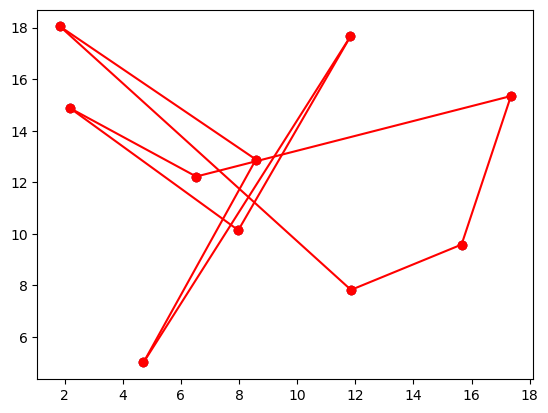

Route: [0 1 2 3 4 5 6 7 8 9]
Cost of route: 119.51211867648853


In [393]:
plot_route(n, points, start_route, cost=cost, M=None)

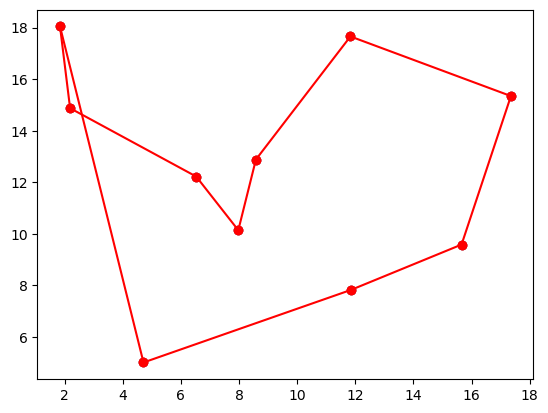

Route: [9 5 4 3 0 2 7 6 8 1]
Cost of route: 72.14166134480605


In [394]:
plot_route(n, points, res, cost=cost, M=None)

In [395]:
seed = 30
rng = np.random.default_rng(seed=seed)

n = 12
ns = np.array([i for i in range(n)])
points = np.array([[2,4,6,8,8,8,8,6,4,2,2,2],[2,2,2,2,4,6,8,8,8,8,6,4]])

start_route = rng.permutation(ns)

kmax = 1_000

res = ex7_part1(n=n, ns=ns, start=start_route, points=points, cost=cost, new_route=swap, T=T1, kmax=kmax, rng=rng)

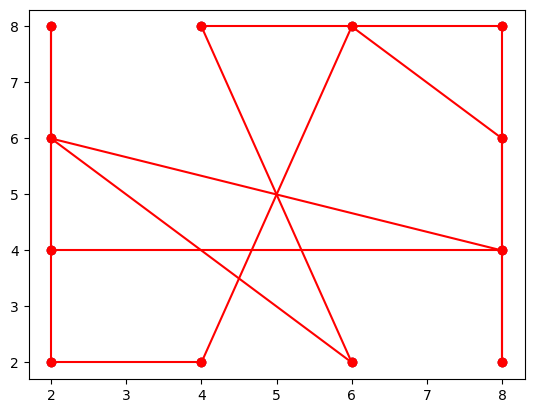

Route: [ 8  6  3  5  7  1  0  9 11  4 10  2]
Cost of route: 68.0


In [396]:
plot_route(n, points, start_route, cost=cost, M=None)

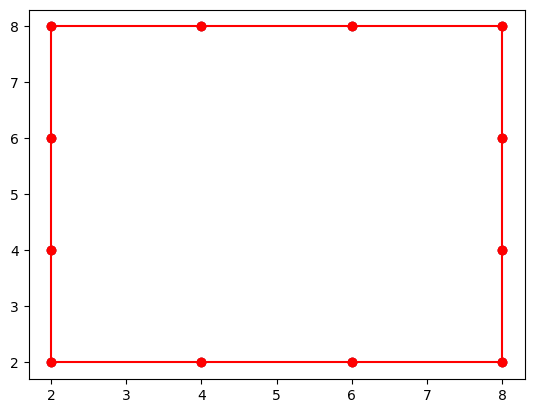

Route: [ 8  7  6  5  4  3  2  1  0 11 10  9]
Cost of route: 24.0


In [397]:
plot_route(n, points, res, cost=cost, M=None)

### Part 2

In [398]:
def cost_matrix(n, route, points, M=None):
    res = 0
    for i in range(n-1):
        p1 = route[i]
        p2 = route[i+1]
        res += M[p1,p2]
    res += M[route[-1],route[0]]
    return res

In [399]:
seed = 30
rng = np.random.default_rng(seed=seed)

M = np.genfromtxt('cost.csv', delimiter=',')
n = np.shape(M)[0]

ns = np.array([i for i in range(n)])
points = rng.uniform(low=0, high=20, size=(2,n))

start_route = np.array([i for i in range(n)])

kmax = 10_000

res = ex7_part1(n=n, ns=ns, start=start_route, points=points, cost=cost_matrix, new_route=swap, T=T1, kmax=kmax, rng=rng, M=M)

In [400]:
print('Start route')
print(f'Route: {start_route}')
print(f'Cost of route: {cost_matrix(n, start_route, points, M)}')

Start route
Route: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Cost of route: 3404.0


In [401]:
print('Found route')
print(f'Route: {res}')
print(f'Cost of route: {cost_matrix(n, res, points, M)}')

Found route
Route: [11  5 10  2 19 16  4  7  9 15 17  6  1  8 13 18 14  3  0 12]
Cost of route: 1188.0
